In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [2]:
#load the CIFAR-10 Dataset
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()
y_train_cifar = to_categorical(y_train_cifar, 10)
y_test_cifar = to_categorical(y_test_cifar, 10)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
#Create the CNN Model
def make_cnn():
    model = Sequential([
        Conv2D(16, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        MaxPooling2D(),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [4]:
# No Processing
cnn = make_cnn()
cnn.fit(x_train_cifar / 255.0, y_train_cifar, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_no = cnn.evaluate(x_test_cifar / 255.0, y_test_cifar, verbose=0)

# MinMaxScaler
def minmax_cifar(imgs):
    imgs = imgs.reshape(-1, 3072)  # Flatten the image to 1D (32 * 32 * 3 = 3072)
    scaler = MinMaxScaler()        # Scale the data between 0 and 1
    imgs = scaler.fit_transform(imgs)  # Fit and transform the training data
    return imgs.reshape(-1, 32, 32, 3)  # Reshape back to 3D (32, 32, 3)
x_train_mm = minmax_cifar(x_train_cifar)
x_test_mm = minmax_cifar(x_test_cifar)
cnn.fit(x_train_mm, y_train_cifar, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_mm = cnn.evaluate(x_test_mm, y_test_cifar, verbose=0)

# StandardScaler
def std_cifar(imgs):
    imgs = imgs.reshape(-1, 3072)
    scaler = StandardScaler()
    imgs = scaler.fit_transform(imgs)
    return imgs.reshape(-1, 32, 32, 3)
x_train_std = std_cifar(x_train_cifar)
x_test_std = std_cifar(x_test_cifar)
cnn.fit(x_train_std, y_train_cifar, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_std = cnn.evaluate(x_test_std, y_test_cifar, verbose=0)

# QuantileTransformer
def qt_cifar(imgs):
    imgs = imgs.reshape(-1, 3072)
    scaler = QuantileTransformer(n_quantiles=200)
    imgs = scaler.fit_transform(imgs)
    return imgs.reshape(-1, 32, 32, 3)
x_train_qt = qt_cifar(x_train_cifar)
x_test_qt = qt_cifar(x_test_cifar)
cnn.fit(x_train_qt, y_train_cifar, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_qt = cnn.evaluate(x_test_qt, y_test_cifar, verbose=0)

# PCA (dimensionality reduction for CIFAR-10)
def pca_cifar(a, b):
    a_f = a.reshape(-1, 3072)
    b_f = b.reshape(-1, 3072)
    pca = PCA(n_components=200)
    a_p = pca.fit_transform(a_f)
    b_p = pca.transform(b_f)
    return a_p.reshape(-1, 10, 20, 1), b_p.reshape(-1, 10, 20, 1)
x_train_pca, x_test_pca = pca_cifar(x_train_cifar, x_test_cifar)
cnn = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(10,20,1)),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.fit(x_train_pca, y_train_cifar, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_pca = cnn.evaluate(x_test_pca, y_test_cifar, verbose=0)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


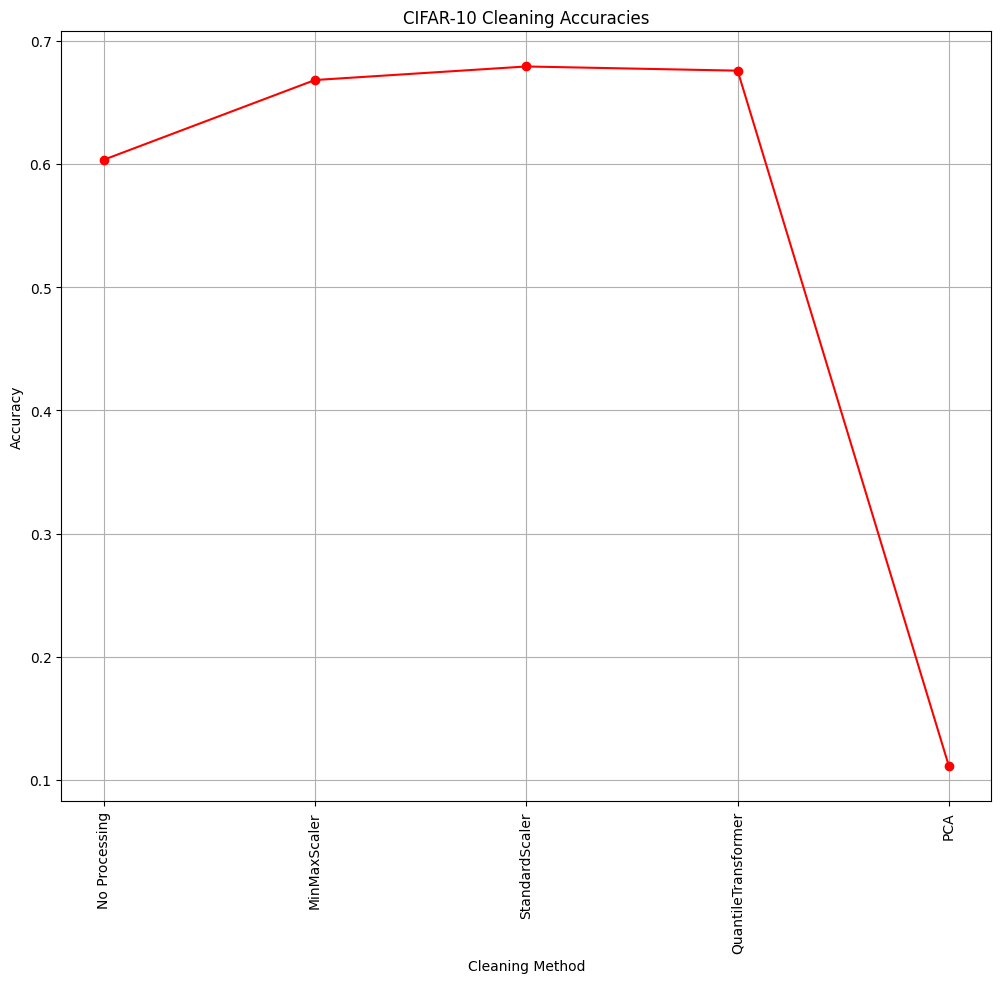

In [6]:
# Accuracy results for CIFAR-10
cifar_accuracies = {
    "No Processing": acc_cnn_no,
    "MinMaxScaler": acc_cnn_mm,
    "StandardScaler": acc_cnn_std,
    "QuantileTransformer": acc_cnn_qt,
    "PCA": acc_cnn_pca
}

# Plotting
plt.figure(figsize=(12, 10))
plt.plot(list(cifar_accuracies.keys()), list(cifar_accuracies.values()), marker='o', linestyle='-', color='r')
plt.title("CIFAR-10 Cleaning Accuracies")
plt.xlabel("Cleaning Method")
plt.ylabel("Accuracy")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()



#**Conclusion for CIFAR-10**

For CIFAR-10, StandardScaler,QuantileTransformer and MinMaxScaler offer modest improvements, but PCA fail to provide significant benefits, with PCA reducing performance dramatically due to the loss of important spatial information in the images. Raw pixel data (after normalization) performs good, as the CNN model benefits from the full, unaltered image data.